In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import warnings
warnings.filterwarnings("ignore")

In [3]:
# get the geo data using GEOparse
gse = GEOparse.get_GEO(geo="GSE134697", destdir="./data")
print("Download complete")
print(gse)

22-Mar-2026 08:11:35 DEBUG utils - Directory ./data already exists. Skipping.
22-Mar-2026 08:11:35 INFO GEOparse - File already exist: using local version.
22-Mar-2026 08:11:35 INFO GEOparse - Parsing ./data\GSE134697_family.soft.gz: 
22-Mar-2026 08:11:35 DEBUG GEOparse - DATABASE: GeoMiame
22-Mar-2026 08:11:35 DEBUG GEOparse - SERIES: GSE134697
22-Mar-2026 08:11:35 DEBUG GEOparse - PLATFORM: GPL16791
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963731
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963732
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963733
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963734
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963735
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963736
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963737
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963738
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963739
22-Mar-2026 08:11:35 DEBUG GEOparse - SAMPLE: GSM3963740
22-Mar-2026 08:11:35 DEBU

Download complete
<SERIES: GSE134697 - 36 SAMPLES, 1 d(s)>


In [4]:
# looking at the sample metadata
for gsm_name, gsm in gse.gsms.items():
    print(gsm_name, gsm.metadata['title'], gsm.metadata['source_name_ch1'])

GSM3963731 ['Neocortex patient 1'] ['Brain']
GSM3963732 ['Hippocampus patient 1'] ['Brain']
GSM3963733 ['Neocortex patient 2'] ['Brain']
GSM3963734 ['Hippocampus patient 2'] ['Brain']
GSM3963735 ['Neocortex patient 3'] ['Brain']
GSM3963736 ['Hippocampus patient 3'] ['Brain']
GSM3963737 ['Neocortex patient 4'] ['Brain']
GSM3963738 ['Hippocampus patient 4'] ['Brain']
GSM3963739 ['Neocortex patient 5'] ['Brain']
GSM3963740 ['Hippocampus patient 5'] ['Brain']
GSM3963741 ['Neocortex patient 6'] ['Brain']
GSM3963742 ['Hippocampus patient 6'] ['Brain']
GSM3963743 ['Neocortex patient 7'] ['Brain']
GSM3963744 ['Hippocampus patient 7'] ['Brain']
GSM3963745 ['Neocortex patient 8'] ['Brain']
GSM3963746 ['Hippocampus patient 8'] ['Brain']
GSM3963747 ['Neocortex patient 9'] ['Brain']
GSM3963748 ['Hippocampus patient 9'] ['Brain']
GSM3963749 ['Neocortex patient 10'] ['Brain']
GSM3963750 ['Hippocampus patient 10'] ['Brain']
GSM3963751 ['Neocortex patient 11'] ['Brain']
GSM3963752 ['Hippocampus patient

In [5]:
for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata.get('titles', ['Unknown'])[0]
    source = gsm.metadata.get('source_name_ch1', ['Unknown'])[0]
    print(gsm_name, title, source)

    #

GSM3963731 Unknown Brain
GSM3963732 Unknown Brain
GSM3963733 Unknown Brain
GSM3963734 Unknown Brain
GSM3963735 Unknown Brain
GSM3963736 Unknown Brain
GSM3963737 Unknown Brain
GSM3963738 Unknown Brain
GSM3963739 Unknown Brain
GSM3963740 Unknown Brain
GSM3963741 Unknown Brain
GSM3963742 Unknown Brain
GSM3963743 Unknown Brain
GSM3963744 Unknown Brain
GSM3963745 Unknown Brain
GSM3963746 Unknown Brain
GSM3963747 Unknown Brain
GSM3963748 Unknown Brain
GSM3963749 Unknown Brain
GSM3963750 Unknown Brain
GSM3963751 Unknown Brain
GSM3963752 Unknown Brain
GSM3963753 Unknown Brain
GSM3963754 Unknown Brain
GSM3963755 Unknown Brain
GSM3963756 Unknown Brain
GSM3963757 Unknown Brain
GSM3963758 Unknown Brain
GSM3963759 Unknown Brain
GSM3963760 Unknown Brain
GSM3963761 Unknown Brain
GSM3963762 Unknown Brain
GSM3963763 Unknown Brain
GSM3963764 Unknown Brain
GSM3963765 Unknown Brain
GSM3963766 Unknown Brain


In [6]:
import pandas as pd

sample_info = []
for gsm_name, gsm in gse.gsms.items():
    sample_info.append({
        'sample_id': gsm_name,
        'title': gsm.metadata['title'][0],
        'source': gsm.metadata['source_name_ch1'][0]
    })

df_samples = pd.DataFrame(sample_info)
df_samples

,sample_id,title,source
0,GSM3963731,Neocortex patient 1,Brain
1,GSM3963732,Hippocampus patient 1,Brain
2,GSM3963733,Neocortex patient 2,Brain
3,GSM3963734,Hippocampus patient 2,Brain
4,GSM3963735,Neocortex patient 3,Brain
5,GSM3963736,Hippocampus patient 3,Brain
6,GSM3963737,Neocortex patient 4,Brain
7,GSM3963738,Hippocampus patient 4,Brain
8,GSM3963739,Neocortex patient 5,Brain
9,GSM3963740,Hippocampus patient 5,Brain


In [6]:
# load the count matrix
import os

# Find the supplementary file that was downloaded
data_dir = "./data"
for root, dirs, files in os.walk(data_dir):
    for file in files:
        print(os.path.join(root, file))

./data\DESeq2_full_results.csv
./data\DESeq2_significant_genes.csv
./data\downregulated_hippocampus.csv
./data\GSE134697_CountMatrix.tsv.gz
./data\GSE134697_family.soft.gz
./data\upregulated_hippocampus.csv
./data\volcano_plot.png


In [7]:
# only soft file was downloaded
import urllib.request

# This line creates a variable that stores the web address of the count matrix file on NCBI's servers
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE134nnn/GSE134697/suppl/GSE134697_CountMatrix.tsv.gz"

# This line tells Python where to save the file on your computer
# It will be saved inside your data folder with the same filename
destination = "./data/GSE134697_CountMatrix.tsv.gz"

# This line actually goes to that web address and downloads the file to your computer
urllib.request.urlretrieve(url, destination)

# This line prints a message so you know it finished
print("Count matrix downloaded successfully")

Count matrix downloaded successfully


In [8]:
count_matrix = pd.read_csv("./data/GSE134697_CountMatrix.tsv.gz", 
                            sep='\t', 
                            index_col=0)

print("Shape of count matrix:", count_matrix.shape)

ParserError: Could not construct index. Requested to use 1 number of columns, but 41 left to parse.

In [8]:
# gzip is a built-in Python library for reading compressed files
# we import it here because our file ends in .gz meaning it is compressed
import gzip

# open the compressed file in read mode
# 'rb' means read in binary mode which is required for compressed files
with gzip.open("./data/GSE134697_CountMatrix.tsv.gz", 'rb') as f:
    
    # read only the first 3 lines so we can see the structure
    # without loading the entire file into memory
    for i in range(3):
        
        # decode converts the binary data into readable text
        line = f.readline().decode('utf-8')
        
        # print each line so we can see it
        print(f"Line {i+1}:")
        print(line)
        print("---")

Line 1:
# Program:featureCounts v1.6.2; Command:"/services/tools/subread/1.6.2/bin/featureCounts" "-T" "32" "-s" "2" "--minOverlap" "10" "-B" "-C" "-Q" "30" "-p" "-g" "gene_id" "-a" "/home/projects/ku_10024/data/Human_data/RefData/Homo_sapiens.GRCh37.85.gtf" "-o" "/home/projects/ku_10024/data/Human_data/Outs/CountMatrix.tsv" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C10-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C11-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C12-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C13-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C14-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C15-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C16-Brain-RNA_D00140_0313.bam" "/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C17-Brain-RNA_D0

In [9]:
# Read the file but skip the first line (the # comment line)
# skiprows=1 tells pandas to ignore line 1 completely
# sep='\t' means columns are separated by tabs
# index_col=0 means use the first column (Geneid) as the row labels
count_matrix = pd.read_csv("./data/GSE134697_CountMatrix.tsv.gz",
                            sep='\t',
                            skiprows=1,
                            index_col=0)

# Print the shape — (number of genes, number of columns)
print("Shape:", count_matrix.shape)

Shape: (57905, 41)


In [10]:
count_matrix.head()

,Chr,Start,End,Strand,Length,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C10-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C11-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C12-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C13-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C14-Brain-RNA_D00140_0313.bam,...,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H2-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H3-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H4-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H5-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H6-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H7-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H8-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-H9-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CTRL-00001-Brain-RNA_D00140_0313.bam,/home/projects/ku_10024/data/Human_data/BamFiles/CTRL-00002-Brain-RNA_D00140_0313.bam
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1,11869;11872;11874;12010;12179;12595;12613;1261...,12227;12227;12227;12057;12227;12721;12697;1272...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,1756,0,0,0,0,0,...,0,0,1,0,0,2,0,0,0,0
ENSG00000227232,1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;...,14363;14363;14363;14404;14411;14970;14970;1497...,14829;14829;14829;14501;14502;15038;15038;1503...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,2073,75,101,76,133,101,...,63,48,77,65,108,83,52,133,85,136
ENSG00000243485,1;1;1;1;1;1,29554;30267;30366;30564;30976;30976,30039;30667;30503;30667;31109;31097,+;+;+;+;+;+,1021,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,1;1;1;1;1,34554;35245;35277;35721;35721,35174;35481;35481;36081;36073,-;-;-;-;-,1219,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,1;1;1,52473;53049;54830,53312;53067;54936,+;+;+,947,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# Right now these are long messy file paths
# We need to see them before we clean them up
print(count_matrix.columns.tolist())

['Chr', 'Start', 'End', 'Strand', 'Length', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C10-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C11-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C12-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C13-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C14-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C15-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C16-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C17-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C1-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C2-Brain-RNA_D00140_0313.bam', '/home/projects/ku_10024/data/Human_data/BamFiles/CHKJ-C3-Brain-RNA_D00140_0313.bam', '/

In [12]:
# The first 5 columns are gene annotations not counts
# We store them separately so we don't lose that information
# iloc means "select by position"
# [:, 0:5] means all rows, columns 0 through 4
annotation_cols = count_matrix.iloc[:, 0:5]

# The actual count data starts at column 5 onwards
# [:, 5:] means all rows, from column 5 to the end
counts = count_matrix.iloc[:, 5:]

# Print shapes to confirm the split worked correctly
print("Annotation columns shape:", annotation_cols.shape)
print("Count matrix shape:", counts.shape)

Annotation columns shape: (57905, 5)
Count matrix shape: (57905, 36)


In [13]:
# First we extract just the filename from the full path
# Each column name looks like: /home/.../CHKJ-C10-Brain-RNA_D00140_0313.bam
# We only want the meaningful part: CHKJ-C10

# .columns gives us all column names
# We loop through each one and extract just the sample ID part

# split('/') splits the path by forward slash into a list
# [-1] takes the last item in that list which is the filename
# split('-Brain')[0] removes everything from '-Brain' onwards
# This leaves us with just CHKJ-C10 or CTRL-00001 etc.

new_column_names = [col.split('/')[-1].split('-Brain')[0] 
                    for col in counts.columns]
counts.columns = new_column_names
counts.columns = counts.columns.str.split('/').str[-1].str.split('-Brain').str[0]


#try_lamda = [lambda counts.columns: col.split('/')[-1].split('-Brain')[0]]
# Now assign these clean names back to the counts DataFrame columns
#counts.columns = 

# Print the new column names to confirm they look right
print(counts.columns.tolist())

['CHKJ-C10', 'CHKJ-C11', 'CHKJ-C12', 'CHKJ-C13', 'CHKJ-C14', 'CHKJ-C15', 'CHKJ-C16', 'CHKJ-C17', 'CHKJ-C1', 'CHKJ-C2', 'CHKJ-C3', 'CHKJ-C4', 'CHKJ-C5', 'CHKJ-C6', 'CHKJ-C7', 'CHKJ-C8', 'CHKJ-C9', 'CHKJ-H10', 'CHKJ-H11', 'CHKJ-H12', 'CHKJ-H13', 'CHKJ-H14', 'CHKJ-H15', 'CHKJ-H16', 'CHKJ-H17', 'CHKJ-H1', 'CHKJ-H2', 'CHKJ-H3', 'CHKJ-H4', 'CHKJ-H5', 'CHKJ-H6', 'CHKJ-H7', 'CHKJ-H8', 'CHKJ-H9', 'CTRL-00001', 'CTRL-00002']


In [14]:
counts.columns = counts.columns.str.replace("-Brain-RNA_D00140_0313.bam", '')
counts.columns

Index(['CHKJ-C10', 'CHKJ-C11', 'CHKJ-C12', 'CHKJ-C13', 'CHKJ-C14', 'CHKJ-C15',
       'CHKJ-C16', 'CHKJ-C17', 'CHKJ-C1', 'CHKJ-C2', 'CHKJ-C3', 'CHKJ-C4',
       'CHKJ-C5', 'CHKJ-C6', 'CHKJ-C7', 'CHKJ-C8', 'CHKJ-C9', 'CHKJ-H10',
       'CHKJ-H11', 'CHKJ-H12', 'CHKJ-H13', 'CHKJ-H14', 'CHKJ-H15', 'CHKJ-H16',
       'CHKJ-H17', 'CHKJ-H1', 'CHKJ-H2', 'CHKJ-H3', 'CHKJ-H4', 'CHKJ-H5',
       'CHKJ-H6', 'CHKJ-H7', 'CHKJ-H8', 'CHKJ-H9', 'CTRL-00001', 'CTRL-00002'],
      dtype='object')

In [15]:
counts

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H5,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9,CTRL-00001,CTRL-00002
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,0,0,0,0
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,63,48,77,65,108,83,52,133,85,136
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215616,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215611,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# deos the same job as the one above
# os.path.basename extracts just the filename from a full path
# .replace removes the unwanted suffix
import os

counts.columns = [
    os.path.basename(col).replace('-Brain-RNA_D00140_0313.bam', '')
    for col in counts.columns
]

print(counts.columns.tolist())

# this looks cleaner

['CHKJ-C10', 'CHKJ-C11', 'CHKJ-C12', 'CHKJ-C13', 'CHKJ-C14', 'CHKJ-C15', 'CHKJ-C16', 'CHKJ-C17', 'CHKJ-C1', 'CHKJ-C2', 'CHKJ-C3', 'CHKJ-C4', 'CHKJ-C5', 'CHKJ-C6', 'CHKJ-C7', 'CHKJ-C8', 'CHKJ-C9', 'CHKJ-H10', 'CHKJ-H11', 'CHKJ-H12', 'CHKJ-H13', 'CHKJ-H14', 'CHKJ-H15', 'CHKJ-H16', 'CHKJ-H17', 'CHKJ-H1', 'CHKJ-H2', 'CHKJ-H3', 'CHKJ-H4', 'CHKJ-H5', 'CHKJ-H6', 'CHKJ-H7', 'CHKJ-H8', 'CHKJ-H9', 'CTRL-00001', 'CTRL-00002']


In [16]:
# We will build this metadata table manually because we know the structure
# Each sample needs three pieces of information:
# 1. sample_id — the sample name
# 2. condition — either Hippocampus or Neocortex
# 3. patient — which patient it came from (for the paired design)

# Start with the list of all sample names
sample_ids = counts.columns.tolist()

# Create empty lists to store condition and patient info
conditions = []
patient_ids = []

# Loop through each sample name and figure out its condition and patient
for sample in sample_ids:
    
    # If the sample name contains '-H' it is a Hippocampus sample
    if '-H' in sample:
        conditions.append('Hippocampus')
        # Extract the patient number from the name
        # 'CHKJ-H10'.split('-H')[1] gives '10'
        patient_ids.append('P' + sample.split('-H')[1])
    
    # If it contains '-C' it is a Neocortex sample from a patient
    elif '-C' in sample:
        conditions.append('Neocortex')
        # 'CHKJ-C10'.split('-C')[1] gives '10'
        patient_ids.append('P' + sample.split('-C')[1])
    
    # If it contains 'CTRL' it is a control sample
    else:
        conditions.append('Control')
        # Controls don't have a matched patient so we label them separately
        patient_ids.append(sample)

# Now build a DataFrame from these three lists
# This creates a table with one row per sample
metadata = pd.DataFrame({
    'sample_id': sample_ids,
    'condition': conditions,
    'patient': patient_ids
})

# Set sample_id as the row index
metadata = metadata.set_index('sample_id')

# Print the full metadata table to confirm everything looks right
print(metadata)
print("\nCondition counts:")
print(metadata['condition'].value_counts())

              condition     patient
sample_id                          
CHKJ-C10      Neocortex         P10
CHKJ-C11      Neocortex         P11
CHKJ-C12      Neocortex         P12
CHKJ-C13      Neocortex         P13
CHKJ-C14      Neocortex         P14
CHKJ-C15      Neocortex         P15
CHKJ-C16      Neocortex         P16
CHKJ-C17      Neocortex         P17
CHKJ-C1       Neocortex          P1
CHKJ-C2       Neocortex          P2
CHKJ-C3       Neocortex          P3
CHKJ-C4       Neocortex          P4
CHKJ-C5       Neocortex          P5
CHKJ-C6       Neocortex          P6
CHKJ-C7       Neocortex          P7
CHKJ-C8       Neocortex          P8
CHKJ-C9       Neocortex          P9
CHKJ-H10    Hippocampus         P10
CHKJ-H11    Hippocampus         P11
CHKJ-H12    Hippocampus         P12
CHKJ-H13    Hippocampus         P13
CHKJ-H14    Hippocampus         P14
CHKJ-H15    Hippocampus         P15
CHKJ-H16    Hippocampus         P16
CHKJ-H17    Hippocampus         P17
CHKJ-H1     Hippocampus     

In [17]:
# Create a list of only the paired patient samples
# We want to keep only samples where condition is Hippocampus or Neocortex
# We exclude the Control samples

# .isin() checks whether each value is in the list we provide
# This returns True for Hippocampus and Neocortex rows, False for Control
paired_mask = metadata['condition'].isin(['Hippocampus', 'Neocortex'])
# paired_mask = metadata['condition'] != 'Control'

# Apply the mask to keep only paired samples in metadata
metadata_paired = metadata[paired_mask]

# Use the same sample names to filter the count matrix columns
# This ensures counts and metadata stay perfectly aligned
counts_paired = counts[metadata_paired.index]

# Confirm the shapes
print("Metadata shape:", metadata_paired.shape)
print("Counts shape:", counts_paired.shape)
print("\nCondition counts after filtering:")
print(metadata_paired['condition'].value_counts())

Metadata shape: (34, 2)
Counts shape: (57905, 34)

Condition counts after filtering:
condition
Neocortex      17
Hippocampus    17
Name: count, dtype: int64


In [18]:
paired_mask

sample_id
CHKJ-C10       True
CHKJ-C11       True
CHKJ-C12       True
CHKJ-C13       True
CHKJ-C14       True
CHKJ-C15       True
CHKJ-C16       True
CHKJ-C17       True
CHKJ-C1        True
CHKJ-C2        True
CHKJ-C3        True
CHKJ-C4        True
CHKJ-C5        True
CHKJ-C6        True
CHKJ-C7        True
CHKJ-C8        True
CHKJ-C9        True
CHKJ-H10       True
CHKJ-H11       True
CHKJ-H12       True
CHKJ-H13       True
CHKJ-H14       True
CHKJ-H15       True
CHKJ-H16       True
CHKJ-H17       True
CHKJ-H1        True
CHKJ-H2        True
CHKJ-H3        True
CHKJ-H4        True
CHKJ-H5        True
CHKJ-H6        True
CHKJ-H7        True
CHKJ-H8        True
CHKJ-H9        True
CTRL-00001    False
CTRL-00002    False
Name: condition, dtype: bool

In [19]:
metadata_paired

,condition,patient
sample_id,,
CHKJ-C10,Neocortex,P10
CHKJ-C11,Neocortex,P11
CHKJ-C12,Neocortex,P12
CHKJ-C13,Neocortex,P13
CHKJ-C14,Neocortex,P14
CHKJ-C15,Neocortex,P15
CHKJ-C16,Neocortex,P16
CHKJ-C17,Neocortex,P17
CHKJ-C1,Neocortex,P1


In [20]:
counts_paired

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H17,CHKJ-H1,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H5,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,2,0,0
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,102,79,63,48,77,65,108,83,52,133
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215616,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215611,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Safety check — confirm counts columns match metadata index exactly
assert list(counts_paired.columns) == list(metadata_paired.index), \
    "Mismatch between counts columns and metadata rows!"
print("Alignment confirmed ✓")

Alignment confirmed ✓


In [22]:
# check the library size
# library size is the total number of RNA reads per sample, it tells us whether all samples were sequenced to a similar depth
library_sizes = counts_paired.sum(axis=0)
print(len(library_sizes))
print(library_sizes)

34
CHKJ-C10    22611273
CHKJ-C11    18516062
CHKJ-C12    19728650
CHKJ-C13    20277127
CHKJ-C14    19772360
CHKJ-C15    17259184
CHKJ-C16    19558983
CHKJ-C17    18591781
CHKJ-C1      9808666
CHKJ-C2     13446557
CHKJ-C3     10214650
CHKJ-C4     11535522
CHKJ-C5      6036563
CHKJ-C6     10942520
CHKJ-C7      9464868
CHKJ-C8     10045115
CHKJ-C9     17007752
CHKJ-H10    21676300
CHKJ-H11    23036310
CHKJ-H12    21629446
CHKJ-H13    26179866
CHKJ-H14    22249047
CHKJ-H15    22964433
CHKJ-H16    16845305
CHKJ-H17    18588018
CHKJ-H1     19870345
CHKJ-H2     21636716
CHKJ-H3     13372985
CHKJ-H4     19559676
CHKJ-H5     16958803
CHKJ-H6     17261664
CHKJ-H7     16252690
CHKJ-H8     16059132
CHKJ-H9     23671377
dtype: int64


In [26]:
library_sizes.sort_values(ascending = False)

CHKJ-H13    26179866
CHKJ-H9     23671377
CHKJ-H11    23036310
CHKJ-H15    22964433
CHKJ-C10    22611273
CHKJ-H14    22249047
CHKJ-H10    21676300
CHKJ-H2     21636716
CHKJ-H12    21629446
CHKJ-C13    20277127
CHKJ-H1     19870345
CHKJ-C14    19772360
CHKJ-C12    19728650
CHKJ-H4     19559676
CHKJ-C16    19558983
CHKJ-C17    18591781
CHKJ-H17    18588018
CHKJ-C11    18516062
CHKJ-H6     17261664
CHKJ-C15    17259184
CHKJ-C9     17007752
CHKJ-H5     16958803
CHKJ-H16    16845305
CHKJ-H7     16252690
CHKJ-H8     16059132
CHKJ-C2     13446557
CHKJ-H3     13372985
CHKJ-C4     11535522
CHKJ-C6     10942520
CHKJ-C3     10214650
CHKJ-C8     10045115
CHKJ-C1      9808666
CHKJ-C7      9464868
CHKJ-C5      6036563
dtype: int64

In [27]:
library_sizes.min()

6036563

In [28]:
library_sizes.max()

26179866

In [29]:
library_sizes.mean()

np.float64(17430286.647058822)

In [30]:
library_sizes.mean().round()

np.float64(17430287.0)

In [31]:
# check how many genes are zeros
total_genes = counts_paired.sum(axis=1)
len(total_genes)

57905

In [32]:
total_genes.sort_values()

Geneid
ENSG00000238643           0
ENSG00000252913           0
ENSG00000254953           0
ENSG00000174914           0
ENSG00000249828           0
                     ...   
ENSG00000198804     7953882
ENSG00000226958    10054455
ENSG00000202198    12398762
ENSG00000258486    35312479
ENSG00000265150    40347409
Length: 57905, dtype: int64

In [33]:
zero_genes = (total_genes == 0).sum()

In [34]:
zero_genes

np.int64(15407)

In [35]:
expressed_genes = (total_genes > 0).sum()
expressed_genes

np.int64(42498)

In [36]:
#percentage of zero genes
(zero_genes/len(total_genes)*100).round()

np.float64(27.0)

In [37]:
# percentage of expressed genes
(expressed_genes/len(total_genes)*100).round()

np.float64(73.0)

In [38]:
library_sizes.values

array([22611273, 18516062, 19728650, 20277127, 19772360, 17259184,
       19558983, 18591781,  9808666, 13446557, 10214650, 11535522,
        6036563, 10942520,  9464868, 10045115, 17007752, 21676300,
       23036310, 21629446, 26179866, 22249047, 22964433, 16845305,
       18588018, 19870345, 21636716, 13372985, 19559676, 16958803,
       17261664, 16252690, 16059132, 23671377])

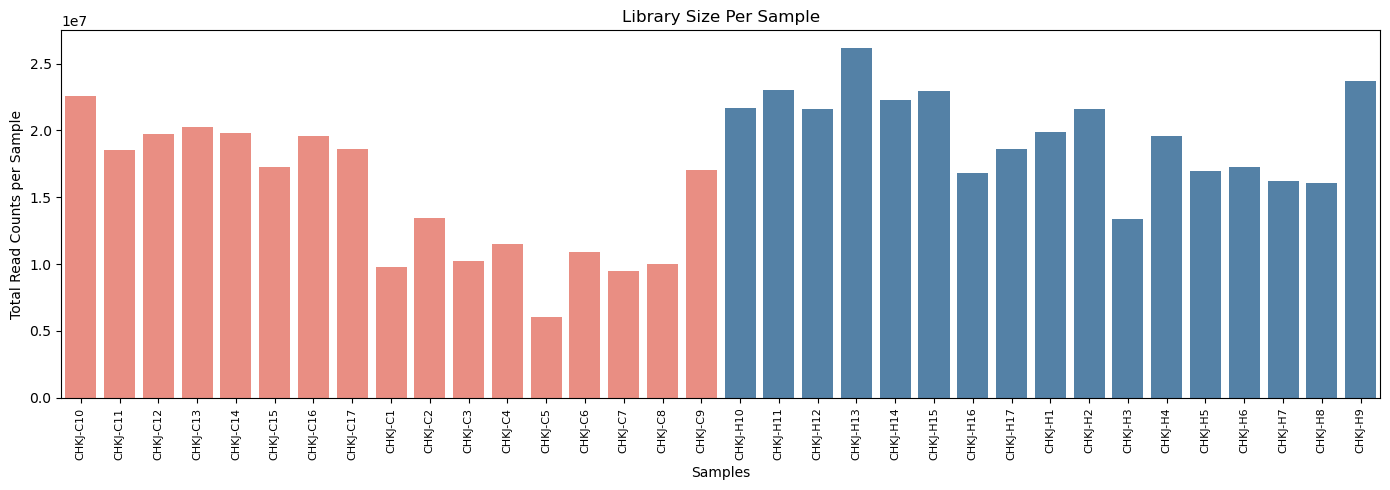

In [40]:
# visualize library sizes
# first set the figure size
plt.figure(figsize=(14,5))

# create a bar plot
# library_size.index gives the sample names for the x axis
# library_sizes.values gives the heights of the bars
colors = ['salmon' if '-C' in s else 'steelblue'
    for s in library_sizes.index]
sns.barplot(x=library_sizes.index, y=library_sizes.values, palette= colors)

# rotate the x axis so that they don't overlap
plt.xticks(rotation=90, fontsize=8)

# axis label
plt.xlabel("Samples")
plt.ylabel("Total Read Counts per Sample")
plt.title("Library Size Per Sample")

# tight_layout automatically adjusts spacing so nothing is cut off
plt.tight_layout()

plt.show()

In [41]:
# investigating the low samples more precisely
library_sizes.sort_values()

CHKJ-C5      6036563
CHKJ-C7      9464868
CHKJ-C1      9808666
CHKJ-C8     10045115
CHKJ-C3     10214650
CHKJ-C6     10942520
CHKJ-C4     11535522
CHKJ-H3     13372985
CHKJ-C2     13446557
CHKJ-H8     16059132
CHKJ-H7     16252690
CHKJ-H16    16845305
CHKJ-H5     16958803
CHKJ-C9     17007752
CHKJ-C15    17259184
CHKJ-H6     17261664
CHKJ-C11    18516062
CHKJ-H17    18588018
CHKJ-C17    18591781
CHKJ-C16    19558983
CHKJ-H4     19559676
CHKJ-C12    19728650
CHKJ-C14    19772360
CHKJ-H1     19870345
CHKJ-C13    20277127
CHKJ-H12    21629446
CHKJ-H2     21636716
CHKJ-H10    21676300
CHKJ-H14    22249047
CHKJ-C10    22611273
CHKJ-H15    22964433
CHKJ-H11    23036310
CHKJ-H9     23671377
CHKJ-H13    26179866
dtype: int64

In [42]:
# calculate how many fold differences between smalles and largest
ratio = library_sizes.max()/library_sizes.min()
round(ratio, 2)

4.34

In [42]:
# flag any samples below 10 million reads as potentially low quality
low_samples = library_sizes[library_sizes < 10_000_000]
low_samples

CHKJ-C1    9808666
CHKJ-C5    6036563
CHKJ-C7    9464868
dtype: int64

In [43]:
# because C5 is an obvious outlier, we remove the outlier pair, we also remove H5
samples_to_remove = ['CHKJ-C5', 'CHKJ-H5']

mask_keep = ~metadata_paired.index.isin(samples_to_remove)

In [44]:
# apply mask to metadata
metadata_no_outlier = metadata_paired[mask_keep]

# apply mask to counts
counts_new = counts_paired[metadata_paired.index[mask_keep]]
counts_new

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H16,CHKJ-H17,CHKJ-H1,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,2,0,0
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,107,102,79,63,48,77,108,83,52,133
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215616,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215611,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
counts_paired

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H17,CHKJ-H1,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H5,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,2,0,0
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,102,79,63,48,77,65,108,83,52,133
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000268020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215616,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000215611,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
expressed_genes

np.int64(42498)

In [47]:
gene_totals = counts_new.sum(axis=1)
gene_totals

Geneid
ENSG00000223972       3
ENSG00000227232    2640
ENSG00000243485       0
ENSG00000237613       0
ENSG00000268020       0
                   ... 
ENSG00000271726       0
ENSG00000215616       0
ENSG00000215611       0
ENSG00000265557       0
ENSG00000238643       0
Length: 57905, dtype: int64

In [48]:
counts_expressed = counts_new[gene_totals > 0]
counts_expressed

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H16,CHKJ-H17,CHKJ-H1,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,2,0,0
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,107,102,79,63,48,77,108,83,52,133
ENSG00000238009,5,1,4,1,3,0,4,0,3,3,...,1,1,2,1,0,0,0,4,0,1
ENSG00000233750,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237683,5,8,7,13,10,8,10,7,13,8,...,4,4,12,6,16,10,11,8,7,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,339,270,260,260,281,299,242,188,207,411,...,199,91,533,433,253,351,336,143,207,336
ENSG00000210194,28,13,10,20,12,14,10,5,6,19,...,3,3,14,14,8,12,13,7,4,10
ENSG00000198727,48644,28252,23992,21989,20216,10790,14778,12646,12335,23556,...,19707,10149,23285,22257,21972,26553,16271,11089,23680,44870


In [49]:
# Apply the counts filter
# Only keep genes if they have at least 10 counts in at least half the number of samples in smallest group
# Smallest group is 16 samples
# Half of 16 is 8, so we require counts to be >=10 in at least 8 samples
min_counts = 10
min_samples = 8

In [50]:
# For each genes count how many sampkes have at least min_counts reads
samples_with_counts = (counts_expressed >= min_counts).sum(axis=1)
len(samples_with_counts)

42320

In [51]:
# keep only genes that meet the threshold
counts_filtered = counts_expressed[samples_with_counts >= min_samples]
counts_filtered

,CHKJ-C10,CHKJ-C11,CHKJ-C12,CHKJ-C13,CHKJ-C14,CHKJ-C15,CHKJ-C16,CHKJ-C17,CHKJ-C1,CHKJ-C2,...,CHKJ-H16,CHKJ-H17,CHKJ-H1,CHKJ-H2,CHKJ-H3,CHKJ-H4,CHKJ-H6,CHKJ-H7,CHKJ-H8,CHKJ-H9
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000227232,75,101,76,133,101,120,154,104,54,37,...,107,102,79,63,48,77,108,83,52,133
ENSG00000237683,5,8,7,13,10,8,10,7,13,8,...,4,4,12,6,16,10,11,8,7,11
ENSG00000241860,20,20,21,19,20,27,18,11,13,25,...,14,15,29,23,12,15,11,8,10,18
ENSG00000228463,7,34,11,22,19,45,48,34,10,17,...,28,23,10,17,13,24,27,14,21,20
ENSG00000225630,214,117,116,96,70,31,45,79,92,191,...,102,46,185,208,182,220,127,90,206,210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,339,270,260,260,281,299,242,188,207,411,...,199,91,533,433,253,351,336,143,207,336
ENSG00000210194,28,13,10,20,12,14,10,5,6,19,...,3,3,14,14,8,12,13,7,4,10
ENSG00000198727,48644,28252,23992,21989,20216,10790,14778,12646,12335,23556,...,19707,10149,23285,22257,21972,26553,16271,11089,23680,44870


In [52]:
# check if metadata and counts have exactly the same samples
metadata_no_outlier

,condition,patient
sample_id,,
CHKJ-C10,Neocortex,P10
CHKJ-C11,Neocortex,P11
CHKJ-C12,Neocortex,P12
CHKJ-C13,Neocortex,P13
CHKJ-C14,Neocortex,P14
CHKJ-C15,Neocortex,P15
CHKJ-C16,Neocortex,P16
CHKJ-C17,Neocortex,P17
CHKJ-C1,Neocortex,P1


In [53]:
counts_filtered.shape[0]

18920

In [54]:
# to confirm if column order matches the row order of metadat exactly
order_match = (counts_filtered.columns == metadata_no_outlier.index).all()
# all() returns True only if every single comparison is True
order_match

np.True_

In [55]:
# import pydeseq2
from pydeseq2.dds import DeseqDataSet

# pydeseq2 requires counts as integers not floats
counts_int = counts_filtered.astype(int)

In [60]:
# create a Dese2 dataset object that holds everything together, like a container
dds = DeseqDataSet(
    counts = counts_int.T,
    metadata = metadata_no_outlier,
    design_factors = ["patient", "condition"] # telling PyDESeq2 that samples from same patients are related. "blocking" it removes between-patient variations so we can see that hippocampus vs neocortex more cearly
)

In [61]:
dds.n_obs

32

In [62]:
dds.n_vars

18920

In [63]:
# fitting the DESeq2 model
# Estimates the size factors - corrects for library size differences
# Estimates gene dispersion - hw variable each gene is across samples
# Fits the statistical model for diferential expression
dds.deseq2()

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 16.17 seconds.

Fitting dispersion trend curve...
... done in 2.05 seconds.

Fitting MAP dispersions...
... done in 19.98 seconds.

Fitting LFCs...
... done in 11.56 seconds.

Calculating cook's distance...
... done in 0.22 seconds.

Replacing 0 outlier genes.



In [66]:
# Look at size factors - one per sample
# size factors close to 1 mean the sample needed ittle correction
# size factor much higher or lower than 1 indicates more correction
size_factors = dds.obsm["size_factors"] if "size_factors" in dds.obsm else dds.size_factors
for sample, sf in zip(metadata_no_outlier.index, dds.size_factors):
    print(f"{sample}: {round(sf, 3)}")

AttributeError: 'DeseqDataSet' object has no attribute 'size_factors'

In [67]:
# First let's see what is actually stored inside our dds object
# This helps us find exactly where size factors are stored
print("Keys in dds.obsm:", list(dds.obsm.keys()))
print("Keys in dds.layers:", list(dds.layers.keys()))
print("Columns in dds.obs:", list(dds.obs.columns))

Keys in dds.obsm: ['design_matrix', '_mu_LFC', '_hat_diagonals']
Keys in dds.layers: ['normed_counts', '_mu_hat', 'cooks']
Columns in dds.obs: ['condition', 'patient', 'size_factors', 'replaceable']


In [64]:
# correction
for sample, sf in zip(dds.obs.index, dds.obs["size_factors"]):
    print(f"{sample}: {round(sf, 3)}")

CHKJ-C10: 1.235
CHKJ-C11: 1.055
CHKJ-C12: 1.099
CHKJ-C13: 1.158
CHKJ-C14: 1.272
CHKJ-C15: 1.137
CHKJ-C16: 1.292
CHKJ-C17: 1.196
CHKJ-C1: 0.611
CHKJ-C2: 0.767
CHKJ-C3: 0.555
CHKJ-C4: 0.602
CHKJ-C6: 0.589
CHKJ-C7: 0.45
CHKJ-C8: 0.506
CHKJ-C9: 0.956
CHKJ-H10: 1.315
CHKJ-H11: 1.403
CHKJ-H12: 1.31
CHKJ-H13: 1.559
CHKJ-H14: 1.413
CHKJ-H15: 1.453
CHKJ-H16: 1.114
CHKJ-H17: 1.192
CHKJ-H1: 1.161
CHKJ-H2: 1.264
CHKJ-H3: 0.745
CHKJ-H4: 1.223
CHKJ-H6: 1.051
CHKJ-H7: 0.899
CHKJ-H8: 0.948
CHKJ-H9: 1.408


In [65]:
# apply vst for visualization
from pydeseq2.utils import load_example_data
from pydeseq2.preprocessing import deseq2_norm

In [66]:
# get normalized counts from the dds object
normalized_counts = dds.layers["normed_counts"]
normalized_counts

array([[6.07446389e+01, 4.04964259e+00, 1.61985704e+01, ...,
        3.93981629e+04, 2.56747340e+02, 2.86714696e+02],
       [9.57167284e+01, 7.58152304e+00, 1.89538076e+01, ...,
        2.67741486e+04, 1.96171909e+02, 3.71494629e+02],
       [6.91329216e+01, 6.36750594e+00, 1.91025178e+01, ...,
        2.18241718e+04, 4.62099002e+02, 2.50152019e+02],
       ...,
       [9.23412393e+01, 8.90036042e+00, 8.90036042e+00, ...,
        1.23370121e+04, 2.20283920e+02, 1.51306127e+02],
       [5.48633372e+01, 7.38544924e+00, 1.05506418e+01, ...,
        2.49839197e+04, 1.73030525e+02, 1.99407130e+02],
       [9.44871702e+01, 7.81472836e+00, 1.27877373e+01, ...,
        3.18769874e+04, 1.49190269e+02, 1.50611128e+02]],
      shape=(32, 18920))

In [67]:
# apply log2 transformation with a psedocount of 1
# +1 prevents log(0) which i undefined mathematically
log2_counts = np.log2(normalized_counts + 1)

In [74]:
# convert back to dataframe with labels
log2_df = pd.DataFrame(
    log2_counts,
    index = metadata_no_outlier.index,
    columns = counts_filtered.index
)

In [75]:
log2_df.shape

(32, 18920)

In [76]:
log2_df

Geneid,ENSG00000227232,ENSG00000237683,ENSG00000241860,ENSG00000228463,ENSG00000225630,ENSG00000237973,ENSG00000248527,ENSG00000235373,ENSG00000228327,ENSG00000237491,...,ENSG00000198938,ENSG00000198840,ENSG00000212907,ENSG00000198886,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
sample_id,,,,,,,,,,,,,,,,,,,,,
CHKJ-C10,5.948242,2.336181,4.104217,2.737579,7.445633,10.054776,11.731434,3.884479,3.961504,3.884479,...,17.159760,14.380135,13.587483,16.013407,15.229690,8.106253,4.565475,15.265877,8.009814,8.168495
CHKJ-C11,6.595694,3.101234,4.318592,5.054044,6.805805,9.319211,11.353492,2.932408,4.879251,4.449508,...,17.177111,14.239763,13.076365,15.502277,14.521997,8.004931,3.735519,14.708607,7.623310,8.541076
CHKJ-C12,6.132020,2.881176,4.329304,3.460229,6.734963,9.120995,10.994651,2.881176,4.726288,4.118824,...,16.814762,14.040256,12.892505,15.107444,14.349901,7.891828,3.335774,14.413705,8.855177,7.972417
CHKJ-C13,6.855643,3.611437,4.121160,4.321314,6.390117,8.425048,10.804768,2.982947,5.599280,4.603344,...,16.393230,13.458081,12.542353,15.097083,14.093281,7.816631,4.191009,14.212420,6.969334,7.707657
CHKJ-C14,6.329259,3.147654,4.063871,3.994404,5.808255,8.216273,10.292579,3.763349,4.665200,4.665200,...,16.138087,13.260701,12.224099,14.737439,13.794962,7.793935,3.383298,13.956293,6.732711,7.186493
CHKJ-C15,6.735795,3.006958,4.629679,5.343143,4.821449,8.516218,10.161969,3.006958,4.908551,4.347408,...,16.600503,13.064290,11.054388,13.705011,12.434639,8.044780,3.735271,13.212864,6.489660,7.259380
CHKJ-C16,6.909248,3.127636,3.900338,5.253690,5.163099,8.066254,9.888141,3.656499,4.400814,4.042647,...,16.381538,13.392406,11.571930,14.057479,12.817187,7.556954,3.127636,13.481698,6.278471,7.075771
CHKJ-C17,6.458707,2.776693,3.350109,4.879111,6.067230,8.300942,10.216690,2.373111,4.077770,3.667392,...,16.545400,13.189526,11.498409,13.902446,12.458418,7.305509,2.373111,13.368301,6.171320,7.056432
CHKJ-C1,6.482277,4.477845,4.477845,4.118627,7.244271,8.463448,11.114825,2.916188,5.004740,4.477845,...,16.528910,13.266137,12.568992,15.243859,14.458790,8.408900,3.435993,14.301703,7.164199,7.349393


In [77]:
log2_df.iloc[:3, :3]

Geneid,ENSG00000227232,ENSG00000237683,ENSG00000241860
sample_id,,,
CHKJ-C10,5.948242,2.336181,4.104217
CHKJ-C11,6.595694,3.101234,4.318592
CHKJ-C12,6.132020,2.881176,4.329304


In [78]:
# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# create a PCA object
# n_components = 10 means that we calculate the first 10 PC
# we will plot PC1 vs PC2 which captures the most variation
# we only need 2 but 10 givs more information
pca = PCA(n_components = 10)

In [79]:
# fit PCA to our log2 normalzed data
# PCA learns the major axes of variation across all genes
# .fit_transform() does two things:
# fit - learns the structure of the data
# transform - projects the data onto the new PCA axes
pca_coordinates = pca.fit_transform(log2_df)
pca_coordinates.shape

(32, 10)

In [80]:
# see how much each variation each component explains
# this tells us how much biological information PC1 and PC@ captures
# explained_variance_ratio_ gives the proportion of total variance
explained_variance = pca.explained_variance_ratio_ * 100
# multiplyng by 100 converts to percentage
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {round(var, 1)}%")
print(f"\nPC1 + PC2 together explain: {round(explained_variance[0] + explained_variance[1], 1)}%")

PC1: 35.0%
PC2: 10.8%
PC3: 7.4%
PC4: 6.1%
PC5: 4.0%
PC6: 3.3%
PC7: 3.2%
PC8: 2.5%
PC9: 2.4%
PC10: 2.1%

PC1 + PC2 together explain: 45.7%


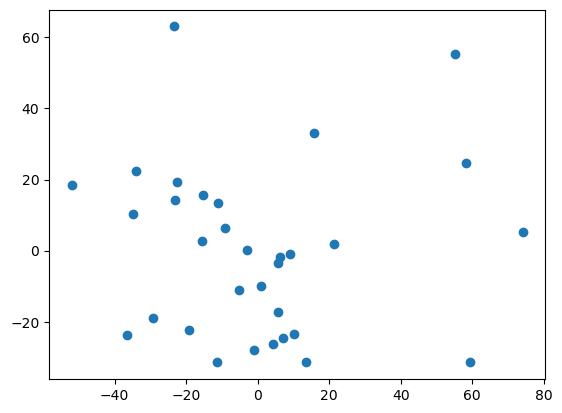

In [81]:
# Plotting PC1 vs PC3 — looking for batch effects:
#plt.scatter(pca_coordinates[:, 0], pca_coordinates[:, 2])

# Plotting PC2 vs PC3:
plt.scatter(pca_coordinates[:, 1], pca_coordinates[:, 2])

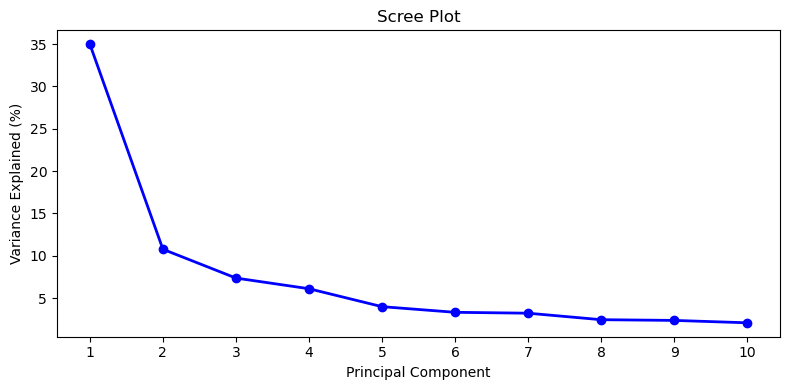

In [82]:
# A scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), explained_variance, 'bo-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Scree Plot')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

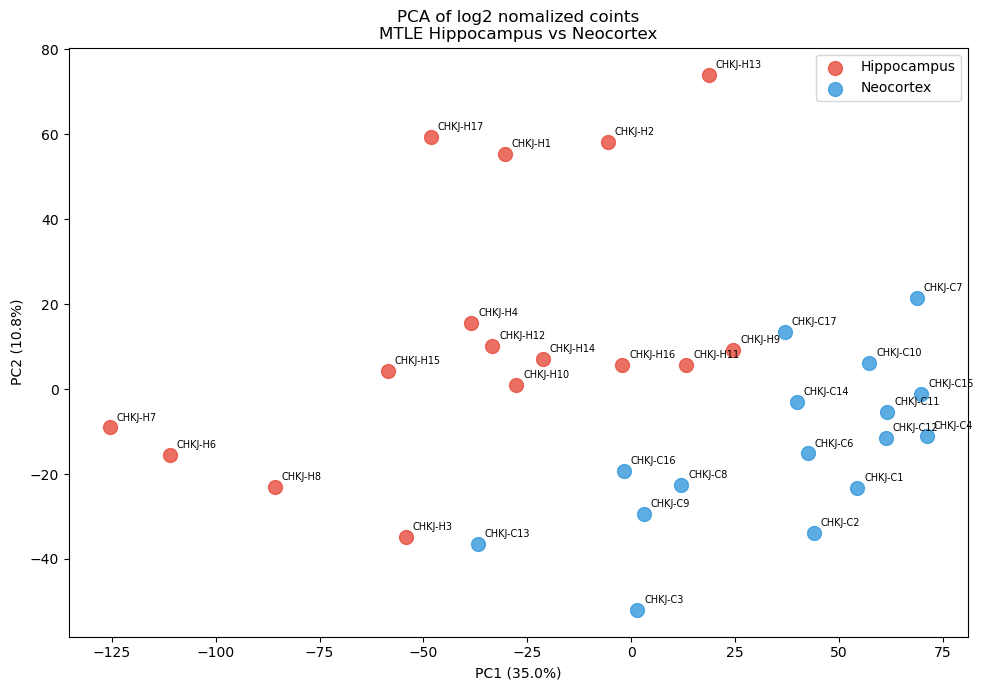

In [84]:
# plot the pca
pca_df = pd.DataFrame({
    'PC1': pca_coordinates[:, 0],
    'PC2': pca_coordinates[:, 1],
    'condition': metadata_no_outlier['condition'],
    'patient': metadata_no_outlier['patient']
})

# Define colors for each condition
colors = {'Hippocampus': '#e74c3c', 'Neocortex': '#3498db'}

# create the plot
plt.figure(figsize=(10,7))

# plot for each condition separately so that we can add a legend
for condition, group in pca_df.groupby('condition'):
    plt.scatter(
        group['PC1'],    # x axis coordinates
        group['PC2'],    # y axis coordinates
        c=colors[condition],
        label=condition,
        s=100,            # size for each dot
        alpha=0.8
    )

# add sample labels next to each dot so we can identify outliers
for idx, row in pca_df.iterrows():
    plt.annotate(
        idx,       # the sample name
        (row['PC1'], row['PC2']),  # the position of the label, data coordinates to annotate
        fontsize=7,
        xytext=(5,5),    #offset the label slightly from the dot
        textcoords='offset points'
    )

# add axis label showing how much variance each PC eplains
plt.xlabel(f"PC1 ({round(explained_variance[0], 1)}%)")
plt.ylabel(f"PC2 ({round(explained_variance[1], 1)}%)")
plt.title("PCA of log2 nomalized coints\nMTLE Hippocampus vs Neocortex")
plt.legend()
plt.tight_layout()
plt.show()


In [85]:
# Check the PC1 and PC2 coordinates of all samples
# This gives us exact numbers to identify outliers objectively

print("PCA coordinates for all samples:")
print(pca_df[['PC1', 'PC2']].sort_values('PC1'))

PCA coordinates for all samples:
                  PC1        PC2
sample_id                       
CHKJ-H7   -125.599809  -9.047556
CHKJ-H6   -111.102803 -15.565636
CHKJ-H8    -85.764225 -23.037249
CHKJ-H15   -58.632690   4.176252
CHKJ-H3    -54.318365 -34.798552
CHKJ-H17   -48.259927  59.356303
CHKJ-H4    -38.491978  15.672032
CHKJ-C13   -36.916266 -36.416136
CHKJ-H12   -33.448966  10.171249
CHKJ-H1    -30.467631  55.272176
CHKJ-H10   -27.659820   0.969351
CHKJ-H14   -21.289373   7.010230
CHKJ-H2     -5.574941  58.247893
CHKJ-H16    -2.136724   5.726848
CHKJ-C16    -1.756158 -19.255230
CHKJ-C3      1.467817 -52.006003
CHKJ-C9      3.039346 -29.321736
CHKJ-C8     12.061422 -22.487494
CHKJ-H11    13.270503   5.586635
CHKJ-H13    18.676840  74.062124
CHKJ-H9     24.635424   9.165104
CHKJ-C17    37.028121  13.432432
CHKJ-C14    39.901963  -3.039294
CHKJ-C6     42.590113 -15.159151
CHKJ-C2     43.940541 -33.987848
CHKJ-C1     54.455956 -23.253624
CHKJ-C10    57.398035   6.134679
CHKJ-C12  

In [86]:
# Identify samples more than 2 standard deviations from mean on either PC
# This is a standard objective outlier detection threshold

pc1_mean = pca_df['PC1'].mean()
pc1_std = pca_df['PC1'].std()
pc2_mean = pca_df['PC2'].mean()
pc2_std = pca_df['PC2'].std()

print(f"PC1 mean: {round(pc1_mean, 1)}, std: {round(pc1_std, 1)}")
print(f"PC2 mean: {round(pc2_mean, 1)}, std: {round(pc2_std, 1)}")
print(f"\nPC1 outlier threshold: below {round(pc1_mean - 2*pc1_std, 1)} or above {round(pc1_mean + 2*pc1_std, 1)}")
print(f"PC2 outlier threshold: below {round(pc2_mean - 2*pc2_std, 1)} or above {round(pc2_mean + 2*pc2_std, 1)}")

# Flag samples outside 2 standard deviations
outliers = pca_df[
    (pca_df['PC1'] < pc1_mean - 2*pc1_std) |
    (pca_df['PC1'] > pc1_mean + 2*pc1_std) |
    (pca_df['PC2'] < pc2_mean - 2*pc2_std) |
    (pca_df['PC2'] > pc2_mean + 2*pc2_std)
]

print(f"\nSamples flagged as outliers:")
print(outliers[['PC1', 'PC2', 'condition']])

PC1 mean: -0.0, std: 52.9
PC2 mean: -0.0, std: 29.4

PC1 outlier threshold: below -105.9 or above 105.9
PC2 outlier threshold: below -58.7 or above 58.7

Samples flagged as outliers:
                  PC1        PC2    condition
sample_id                                    
CHKJ-H13    18.676840  74.062124  Hippocampus
CHKJ-H17   -48.259927  59.356303  Hippocampus
CHKJ-H6   -111.102803 -15.565636  Hippocampus
CHKJ-H7   -125.599809  -9.047556  Hippocampus


In [87]:
# Based on PCA outlier analysis we remove two patient pairs
# Pair 7: CHKJ-H7 (PC1 outlier) and CHKJ-C7 (low library size, confirmed outlier)
# Pair 13: CHKJ-H13 (PC2 outlier) and CHKJ-C13 (also displaced on PC2)

# These removals are justified by two independent QC methods:
# 1. Library size analysis flagged C7
# 2. PCA flagged H7 and H13 as statistical outliers beyond 2 standard deviations

samples_to_remove_pca = ['CHKJ-H7', 'CHKJ-C7', 'CHKJ-H13', 'CHKJ-C13']

# Create mask keeping everything NOT in removal list
keep_mask_pca = ~metadata_no_outlier.index.isin(samples_to_remove_pca)

# Apply to both metadata and counts simultaneously
metadata_final = metadata_no_outlier[keep_mask_pca]
counts_final = counts_filtered[metadata_no_outlier.index[keep_mask_pca]]

# Also filter the log2 DataFrame for future visualization
log2_final = log2_df[keep_mask_pca]

print("Samples removed:", samples_to_remove_pca)
print("Remaining samples:", metadata_final.shape[0])
print("\nCondition counts:")
print(metadata_final['condition'].value_counts())
print("\nPatient pairs remaining:", metadata_final.shape[0] // 2)

Samples removed: ['CHKJ-H7', 'CHKJ-C7', 'CHKJ-H13', 'CHKJ-C13']
Remaining samples: 28

Condition counts:
condition
Neocortex      14
Hippocampus    14
Name: count, dtype: int64

Patient pairs remaining: 14


In [88]:
# convert back to dataframe with labels
log2_df = pd.DataFrame(
    log2_counts,
    index = metadata_no_outlier.index,
    columns = counts_filtered.index
)

In [92]:
# plot the pca
pca_df = pd.DataFrame({
    'PC1': pca_coordinates[:, 0],
    'PC2': pca_coordinates[:, 1],
    'condition': metadata_final['condition'],
    'patient': metadata_final['patient']
})

# Define colors for each condition
colors = {'Hippocampus': '#e74c3c', 'Neocortex': '#3498db'}

# create the plot
plt.figure(figsize=(10,7))

# plot for each condition separately so that we can add a legend
for condition, group in pca_df.groupby('condition'):
    plt.scatter(
        group['PC1'],    # x axis coordinates
        group['PC2'],    # y axis coordinates
        c=colors[condition],
        label=condition,
        s=100,            # size for each dot
        alpha=0.8
    )

# add sample labels next to each dot so we can identify outliers
for idx, row in pca_df.iterrows():
    plt.annotate(
        idx,       # the sample name
        (row['PC1'], row['PC2']),  # the position of the label
        fontsize=7,
        xytext=(5,5),    #offset the label slightly from the dot
        textcoords='offset points'
    )

# add axis label showing how much variance each PC eplains
plt.xlabel(f"PC1 ({round(explained_variance[0], 1)}%)")
plt.ylabel(f"PC2 ({round(explained_variance[1], 1)}%)")
plt.title("PCA of log2 nomalized coints\nMTLE Hippocampus vs Neocortex")
plt.legend()
plt.tight_layout()
plt.show()


ValueError: array length 32 does not match index length 28

In [89]:
# Rerun PCA on the filtered log2 matrix
# log2_final has 28 samples after outlier removal
pca2 = PCA(n_components=10)

# fit_transform learns the structure and projects the data
# log2_final has samples as rows, genes as columns — correct orientation
pca_coordinates2 = pca2.fit_transform(log2_final)

# Calculate explained variance
explained_variance2 = pca2.explained_variance_ratio_ * 100

print("PCA rerun complete")
print("Number of samples:", pca_coordinates2.shape[0])
for i, var in enumerate(explained_variance2[:5]):
    print(f"PC{i+1}: {round(var, 1)}%")
print(f"\nPC1 + PC2: {round(explained_variance2[0] + explained_variance2[1], 1)}%")

PCA rerun complete
Number of samples: 28
PC1: 33.4%
PC2: 10.4%
PC3: 8.8%
PC4: 5.9%
PC5: 4.4%

PC1 + PC2: 43.8%


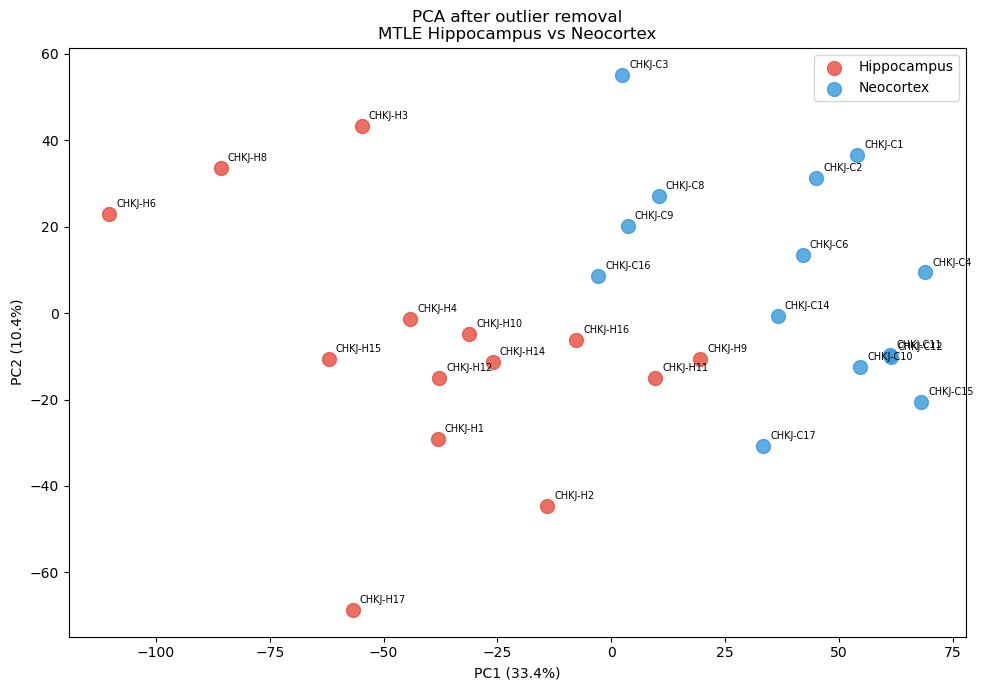

In [90]:
# Now build pca_df using metadata_final which has 28 samples
# and pca_coordinates2 which also has 28 rows — they match
pca_df2 = pd.DataFrame({
    'PC1': pca_coordinates2[:, 0],
    'PC2': pca_coordinates2[:, 1],
    'condition': metadata_final['condition'],
    'patient': metadata_final['patient']
})

# Plot
colors = {'Hippocampus': '#e74c3c', 'Neocortex': '#3498db'}

plt.figure(figsize=(10, 7))

for condition, group in pca_df2.groupby('condition'):
    plt.scatter(
        group['PC1'],
        group['PC2'],
        c=colors[condition],
        label=condition,
        s=100,
        alpha=0.8
    )

for idx, row in pca_df2.iterrows():
    plt.annotate(
        idx,
        (row['PC1'], row['PC2']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel(f"PC1 ({round(explained_variance2[0], 1)}%)")
plt.ylabel(f"PC2 ({round(explained_variance2[1], 1)}%)")
plt.title("PCA after outlier removal\nMTLE Hippocampus vs Neocortex")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# We need to rebuild the dds object because we removed samples after
# the original dds was created
# Always rebuild dds when your counts or metadata change

# Confirm alignment before building
order_match = (counts_final.columns == metadata_final.index).all()
print("Counts and metadata aligned:", order_match)

# If not aligned fix it
if not order_match:
    counts_final = counts_final[metadata_final.index]
    print("Reordered — now aligned:", 
          (counts_final.columns == metadata_final.index).all())

# Convert to integers — required by DESeq2
counts_final_int = counts_final.astype(int)

# Rebuild the DeseqDataSet with final clean data
dds_final = DeseqDataSet(
    counts=counts_final_int.T,
    metadata=metadata_final,
    design_factors=["patient", "condition"]
)

print("\nFinal DESeq2 object created")
print("Samples:", dds_final.n_obs)
print("Genes:", dds_final.n_vars)

Counts and metadata aligned: True

Final DESeq2 object created
Samples: 28
Genes: 18920


In [92]:
# This runs the full DESeq2 pipeline on our clean final dataset
# It estimates dispersions and fits the negative binomial model
# This is the core statistical step — may take a few minutes

dds_final.deseq2()

print("DESeq2 complete")

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 15.48 seconds.

Fitting dispersion trend curve...
... done in 1.94 seconds.

Fitting MAP dispersions...
... done in 18.44 seconds.

Fitting LFCs...
... done in 10.95 seconds.

Calculating cook's distance...


DESeq2 complete


... done in 0.21 seconds.

Replacing 0 outlier genes.



In [93]:
from pydeseq2.ds import DeseqStats

# DeseqStats runs the statistical tests on our fitted model
# contrast specifies exactly what comparison we want
# We are comparing Hippocampus vs Neocortex
# The format is ["variable", "numerator", "denominator"]
# Hippocampus is numerator — positive fold changes mean higher in Hippocampus
# Neocortex is denominator — it is our reference condition

stat_res = DeseqStats(
    dds_final,
    contrast=["condition", "Hippocampus", "Neocortex"]
)

# .summary() runs the Wald test and applies
# Benjamini-Hochberg multiple testing correction
print(stat_res.summary())
stat_res

print("Statistical testing complete")

Running Wald tests...
... done in 5.70 seconds.



Log2 fold change & Wald test p-value: condition Hippocampus vs Neocortex
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Geneid                                                                        
ENSG00000227232     76.221185       -0.056335  0.123649 -0.455603  0.648675   
ENSG00000237683      7.378245        0.061714  0.366162  0.168542  0.866157   
ENSG00000241860     16.217444       -0.418398  0.190201 -2.199765  0.027824   
ENSG00000228463     19.055021       -0.448656  0.180663 -2.483393  0.013014   
ENSG00000225630    157.568506        0.160073  0.211396  0.757221  0.448918   
...                       ...             ...       ...       ...       ...   
ENSG00000198695    302.871129       -0.557213  0.131933 -4.223455  0.000024   
ENSG00000210194     11.005058       -0.797310  0.243415 -3.275518  0.001055   
ENSG00000198727  22785.370343       -0.150284  0.124694 -1.205219  0.228119   
ENSG00000210195    193.217070       -0.496278  0.174213 -2

In [94]:
# stat_res.results_df contains the full results table
# We store it as a variable for easy manipulation
results = stat_res.results_df

# Sort by adjusted p-value so most significant genes appear first
results_sorted = results.sort_values('padj')

print("Total genes tested:", len(results))
print("\nFirst 10 most significant genes:")
print(results_sorted.head(10))
results_sorted

Total genes tested: 18920

First 10 most significant genes:
                    baseMean  log2FoldChange     lfcSE       stat  \
Geneid                                                              
ENSG00000113805   488.596848       -1.524971  0.119551 -12.755793   
ENSG00000156140    89.387496       -1.951474  0.154325 -12.645224   
ENSG00000110931  2163.299620       -1.711397  0.141740 -12.074207   
ENSG00000184845   179.734453       -1.961053  0.163410 -12.000792   
ENSG00000154080    56.251550        1.907765  0.161132  11.839744   
ENSG00000141469   679.266370        2.113299  0.188130  11.233188   
ENSG00000221869   337.200942        1.360736  0.124095  10.965250   
ENSG00000253846   148.244120        0.863598  0.080062  10.786575   
ENSG00000198734    86.445578        2.698019  0.253107  10.659608   
ENSG00000100628    29.607221       -2.612550  0.247165 -10.570064   

                       pvalue          padj  
Geneid                                       
ENSG00000113805  2.

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Geneid,,,,,,
ENSG00000113805,488.596848,-1.524971,0.119551,-12.755793,2.894143e-37,5.475718e-33
ENSG00000156140,89.387496,-1.951474,0.154325,-12.645224,1.188852e-36,1.124654e-32
ENSG00000110931,2163.299620,-1.711397,0.141740,-12.074207,1.445510e-33,9.116351e-30
ENSG00000184845,179.734453,-1.961053,0.163410,-12.000792,3.519144e-33,1.664555e-29
ENSG00000154080,56.251550,1.907765,0.161132,11.839744,2.431942e-32,9.202468e-29
...,...,...,...,...,...,...
ENSG00000269374,24.200408,0.000096,0.159850,0.000601,9.995207e-01,9.997320e-01
ENSG00000184922,435.633180,0.000046,0.129278,0.000360,9.997131e-01,9.997660e-01
ENSG00000225014,11.305113,-0.000128,0.326267,-0.000393,9.996867e-01,9.997660e-01


In [95]:
# Apply standard significance thresholds
# padj < 0.05 — statistically significant after multiple testing correction
# abs(log2FoldChange) > 1 — at least 2 fold change, biologically meaningful

# First remove rows where padj is NaN
# DESeq2 sets padj to NaN for genes with very low counts or outliers
results_clean = results.dropna(subset=['padj'])

# Count significant genes at different thresholds
sig_genes = results_clean[results_clean['padj'] < 0.05]
sig_genes_fc = results_clean[
    (results_clean['padj'] < 0.05) &
    (abs(results_clean['log2FoldChange']) > 1)
]

# Split into upregulated and downregulated
# Upregulated — higher in Hippocampus (positive fold change)
upregulated = sig_genes_fc[sig_genes_fc['log2FoldChange'] > 1]
# Downregulated — lower in Hippocampus (negative fold change)
downregulated = sig_genes_fc[sig_genes_fc['log2FoldChange'] < -1]

print(f"Total genes after removing NaN: {len(results_clean)}")
print(f"\nSignificant genes (padj < 0.05): {len(sig_genes)}")
print(f"Significant + fold change > 2x: {len(sig_genes_fc)}")
print(f"\nUpregulated in Hippocampus: {len(upregulated)}")
print(f"Downregulated in Hippocampus: {len(downregulated)}")

Total genes after removing NaN: 18920

Significant genes (padj < 0.05): 10165
Significant + fold change > 2x: 1739

Upregulated in Hippocampus: 904
Downregulated in Hippocampus: 835


In [96]:
# mygene is a Python library that queries the MyGene.info database
# It converts Ensembl IDs to gene symbols, names, and other annotations
# This is one of the fastest and most reliable gene ID mapping tools

import subprocess
subprocess.run(['pip', 'install', 'mygene'], capture_output=True)

import mygene
mg = mygene.MyGeneInfo()

print("mygene loaded successfully")

mygene loaded successfully


In [97]:
# Get the list of all Ensembl IDs in our results
ensembl_ids = results_sorted.index.tolist()

# Query MyGene.info database
# fields='symbol,name,entrezgene' requests gene symbol, full name, and entrez ID
# species='human' restricts to human genes
# verbose=False suppresses progress messages
gene_info = mg.querymany(
    ensembl_ids,
    scopes='ensembl.gene',
    fields='symbol,name',
    species='human',
    verbose=False
)

print(f"Queried {len(ensembl_ids)} genes")
print(f"Got information for {len(gene_info)} entries")
print("\nExample of first result:")
print(gene_info[0])

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Queried 18920 genes
Got information for 18923 entries

Example of first result:
{'query': 'ENSG00000113805', '_id': '5067', '_score': 32.915394, 'name': 'contactin 3', 'symbol': 'CNTN3'}


In [98]:
# Check what gene_info actually contains
print("Number of results returned:", len(gene_info))
print("\nFirst 3 entries:")
for entry in gene_info[:3]:
    print(entry)

Number of results returned: 18923

First 3 entries:
{'query': 'ENSG00000113805', '_id': '5067', '_score': 32.915394, 'name': 'contactin 3', 'symbol': 'CNTN3'}
{'query': 'ENSG00000156140', '_id': '9508', '_score': 32.915, 'name': 'ADAM metallopeptidase with thrombospondin type 1 motif 3', 'symbol': 'ADAMTS3'}
{'query': 'ENSG00000110931', '_id': '10645', '_score': 32.91523, 'name': 'calcium/calmodulin dependent protein kinase kinase 2', 'symbol': 'CAMKK2'}


In [99]:
# Convert the list of results into a clean dictionary
id_to_symbol = {}

for entry in gene_info:
    ensembl_id = entry['query']
    symbol = entry.get('symbol', ensembl_id)
    id_to_symbol[ensembl_id] = symbol

# Add gene symbols as a new column in results_sorted
results_sorted['gene_symbol'] = results_sorted.index.map(id_to_symbol)

# Add to sig_genes_fc for later use
sig_genes_fc = sig_genes_fc.copy()
sig_genes_fc['gene_symbol'] = sig_genes_fc.index.map(id_to_symbol)

# Add to upregulated and downregulated separately
upregulated = upregulated.copy()
downregulated = downregulated.copy()
upregulated['gene_symbol'] = upregulated.index.map(id_to_symbol)
downregulated['gene_symbol'] = downregulated.index.map(id_to_symbol)

print("Gene symbols added successfully")
print("\nTop 10 most significant genes with names:")
print(results_sorted[['gene_symbol', 'baseMean',
                        'log2FoldChange', 'padj']].head(10))

print("\nTop 10 upregulated in Hippocampus:")
print(upregulated.sort_values('log2FoldChange', 
      ascending=False)[['gene_symbol', 'log2FoldChange', 'padj']].head(10))

print("\nTop 10 downregulated in Hippocampus:")
print(downregulated.sort_values('log2FoldChange',
      ascending=True)[['gene_symbol', 'log2FoldChange', 'padj']].head(10))

Gene symbols added successfully

Top 10 most significant genes with names:
                gene_symbol     baseMean  log2FoldChange          padj
Geneid                                                                
ENSG00000113805       CNTN3   488.596848       -1.524971  5.475718e-33
ENSG00000156140     ADAMTS3    89.387496       -1.951474  1.124654e-32
ENSG00000110931      CAMKK2  2163.299620       -1.711397  9.116351e-30
ENSG00000184845        DRD1   179.734453       -1.961053  1.664555e-29
ENSG00000154080       CHST9    56.251550        1.907765  9.202468e-29
ENSG00000141469     SLC14A1   679.266370        2.113299  8.835107e-26
ENSG00000221869       CEBPD   337.200942        1.360736  1.517532e-24
ENSG00000253846    PCDHGA10   148.244120        0.863598  9.421264e-24
ENSG00000198734          F5    86.445578        2.698019  3.305918e-23
ENSG00000100628        ASB2    29.607221       -2.612550  7.761244e-23

Top 10 upregulated in Hippocampus:
                     gene_symbol  log

In [100]:
# Save the full results table with gene symbols
results_sorted.to_csv('./data/DESeq2_full_results.csv')

# Save only significant genes with fold change filter
sig_genes_fc.to_csv('./data/DESeq2_significant_genes.csv')

# Save upregulated and downregulated separately
upregulated.sort_values('log2FoldChange', 
                         ascending=False).to_csv('./data/upregulated_hippocampus.csv')
downregulated.sort_values('log2FoldChange', 
                           ascending=True).to_csv('./data/downregulated_hippocampus.csv')

print("Files saved successfully:")
print("- DESeq2_full_results.csv")
print("- DESeq2_significant_genes.csv")
print("- upregulated_hippocampus.csv")
print("- downregulated_hippocampus.csv")
print(f"\nTotal significant DEGs saved: {len(sig_genes_fc)}")


Files saved successfully:
- DESeq2_full_results.csv
- DESeq2_significant_genes.csv
- upregulated_hippocampus.csv
- downregulated_hippocampus.csv

Total significant DEGs saved: 1739


```

---

## Where We Are in the Pipeline
```
✓ Load and clean data
✓ Quality control
✓ Normalization
✓ PCA and outlier removal
✓ Differential expression analysis
✓ Gene ID mapping
✓ Results interpretation

→ NEXT: Volcano plot — visualize all results at once
→ Then: Heatmap — visualize top gene patterns
→ Then: Pathway analysis — what biology do these genes represent

In [101]:
# Create a copy of results for plotting
# We need to handle NaN padj values by filling them with 1
# (non-significant) so they don't cause errors
volcano_data = results_sorted.copy()
volcano_data['padj'] = volcano_data['padj'].fillna(1)

# Calculate -log10 padj for y axis
# Small padj = large -log10 value = high on plot = significant
volcano_data['neg_log10_padj'] = -np.log10(volcano_data['padj'] + 1e-300)
# The 1e-300 prevents log(0) for extremely significant genes

# Classify each gene into one of three categories for coloring
# This creates a new column called 'category'
def classify_gene(row):
    # Upregulated — significant AND positive fold change > 1
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return 'Upregulated'
    # Downregulated — significant AND negative fold change < -1
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return 'Downregulated'
    # Not significant or small fold change
    else:
        return 'Not significant'

volcano_data['category'] = volcano_data.apply(classify_gene, axis=1)

# Count genes in each category
print("Gene categories:")
print(volcano_data['category'].value_counts())

Gene categories:
category
Not significant    17181
Upregulated          904
Downregulated        835
Name: count, dtype: int64


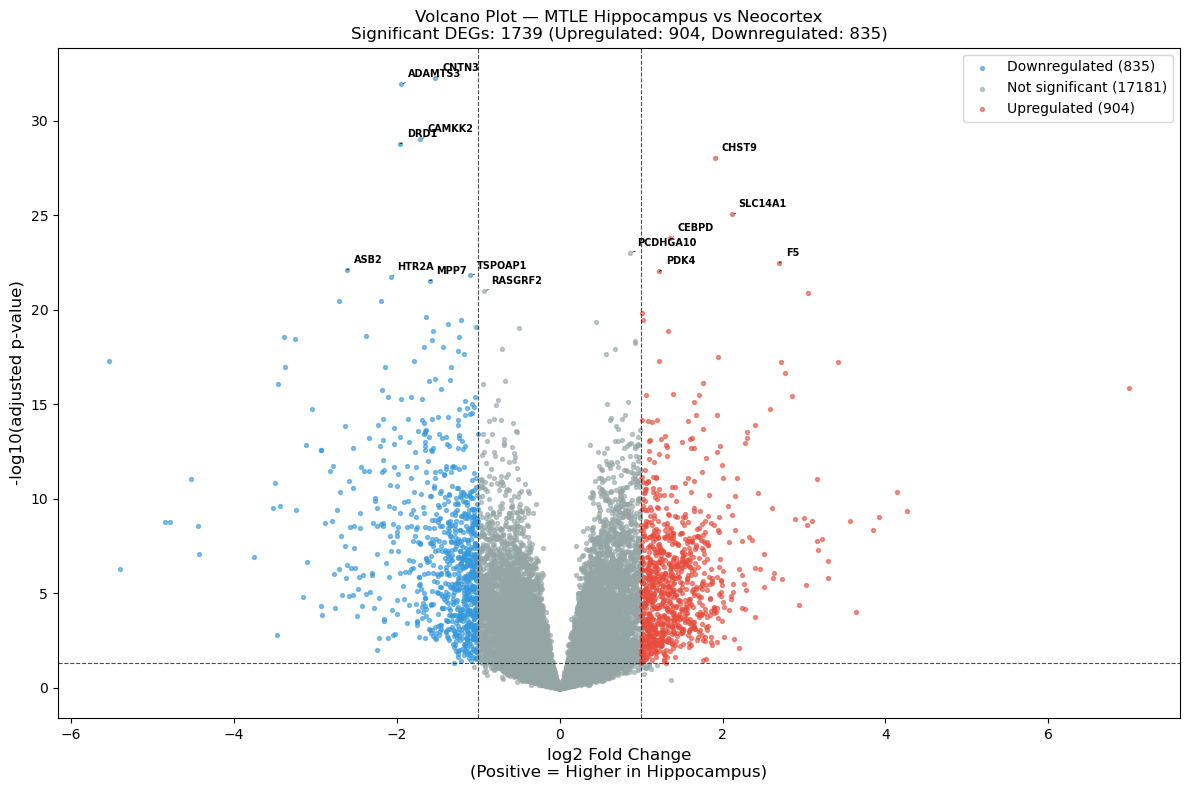

Volcano plot saved to ./data/volcano_plot.png


In [102]:
# Define colors for each category
color_map = {
    'Upregulated': '#e74c3c',      # red
    'Downregulated': '#3498db',    # blue
    'Not significant': '#95a5a6'   # grey
}

plt.figure(figsize=(12, 8))

# Plot each category separately so we get proper legend and colors
for category, group in volcano_data.groupby('category'):
    plt.scatter(
        group['log2FoldChange'],
        group['neg_log10_padj'],
        c=color_map[category],
        label=f"{category} ({len(group)})",
        alpha=0.6,
        s=8          # small dot size because we have 18920 genes
    )

# Add threshold lines so readers can see our cutoffs clearly
# Vertical lines at log2FC = 1 and -1 (2 fold change)
plt.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Horizontal line at padj = 0.05
# -log10(0.05) = 1.301
plt.axhline(y=-np.log10(0.05), color='black', 
            linestyle='--', linewidth=0.8, alpha=0.7)

# Label the top 15 most significant genes by name
# These are the genes worth highlighting on the plot
top_genes = results_sorted.head(15)

for idx, row in top_genes.iterrows():
    if idx in volcano_data.index:
        plt.annotate(
            row['gene_symbol'],
            (row['log2FoldChange'],
             -np.log10(volcano_data.loc[idx, 'padj'] + 1e-300)),
            fontsize=7,
            fontweight='bold',
            xytext=(5, 5),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='-', color='black',
                          lw=0.5)
        )

plt.xlabel('log2 Fold Change\n(Positive = Higher in Hippocampus)',
           fontsize=12)
plt.ylabel('-log10(adjusted p-value)', fontsize=12)
plt.title('Volcano Plot — MTLE Hippocampus vs Neocortex\n'
          f'Significant DEGs: {len(sig_genes_fc)} '
          f'(Upregulated: 904, Downregulated: 835)',
          fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('./data/volcano_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Volcano plot saved to ./data/volcano_plot.png")

In [103]:
# We will plot the top 50 most significant genes
# These give the clearest visual signal

# Get top 50 significant genes by padj
top50_genes = results_sorted[
    results_sorted['padj'] < 0.05
].head(50).index.tolist()

# Get their gene symbols for labelling
top50_symbols = results_sorted.loc[top50_genes, 'gene_symbol'].tolist()

# Extract the log2 normalized expression for these genes
# log2_final has samples as rows and genes as columns
# We select only our top 50 genes
heatmap_data = log2_final[top50_genes]

# Transpose so genes are rows and samples are columns
# This is the standard heatmap orientation
heatmap_data = heatmap_data.T

# Replace Ensembl IDs with gene symbols as row labels
heatmap_data.index = top50_symbols

print("Heatmap data shape:", heatmap_data.shape)
print("Rows are genes, columns are samples")
print("\nFirst 3 gene names:", top50_symbols[:3])

Heatmap data shape: (50, 28)
Rows are genes, columns are samples

First 3 gene names: ['CNTN3', 'ADAMTS3', 'CAMKK2']


In [105]:
# To create the  sample annotation for the color bar
# Color bar should be above the heatmap showing  which samples belong to each tissue

# Create a color mapping the annotation bar
condition_color = metadata_final['condition'].map({
    'Hippocampus': '#e74c3c',
    'Neocortex': '#3498db'
})

condition_color.head()

sample_id
CHKJ-C10    #3498db
CHKJ-C11    #3498db
CHKJ-C12    #3498db
CHKJ-C14    #3498db
CHKJ-C15    #3498db
Name: condition, dtype: object

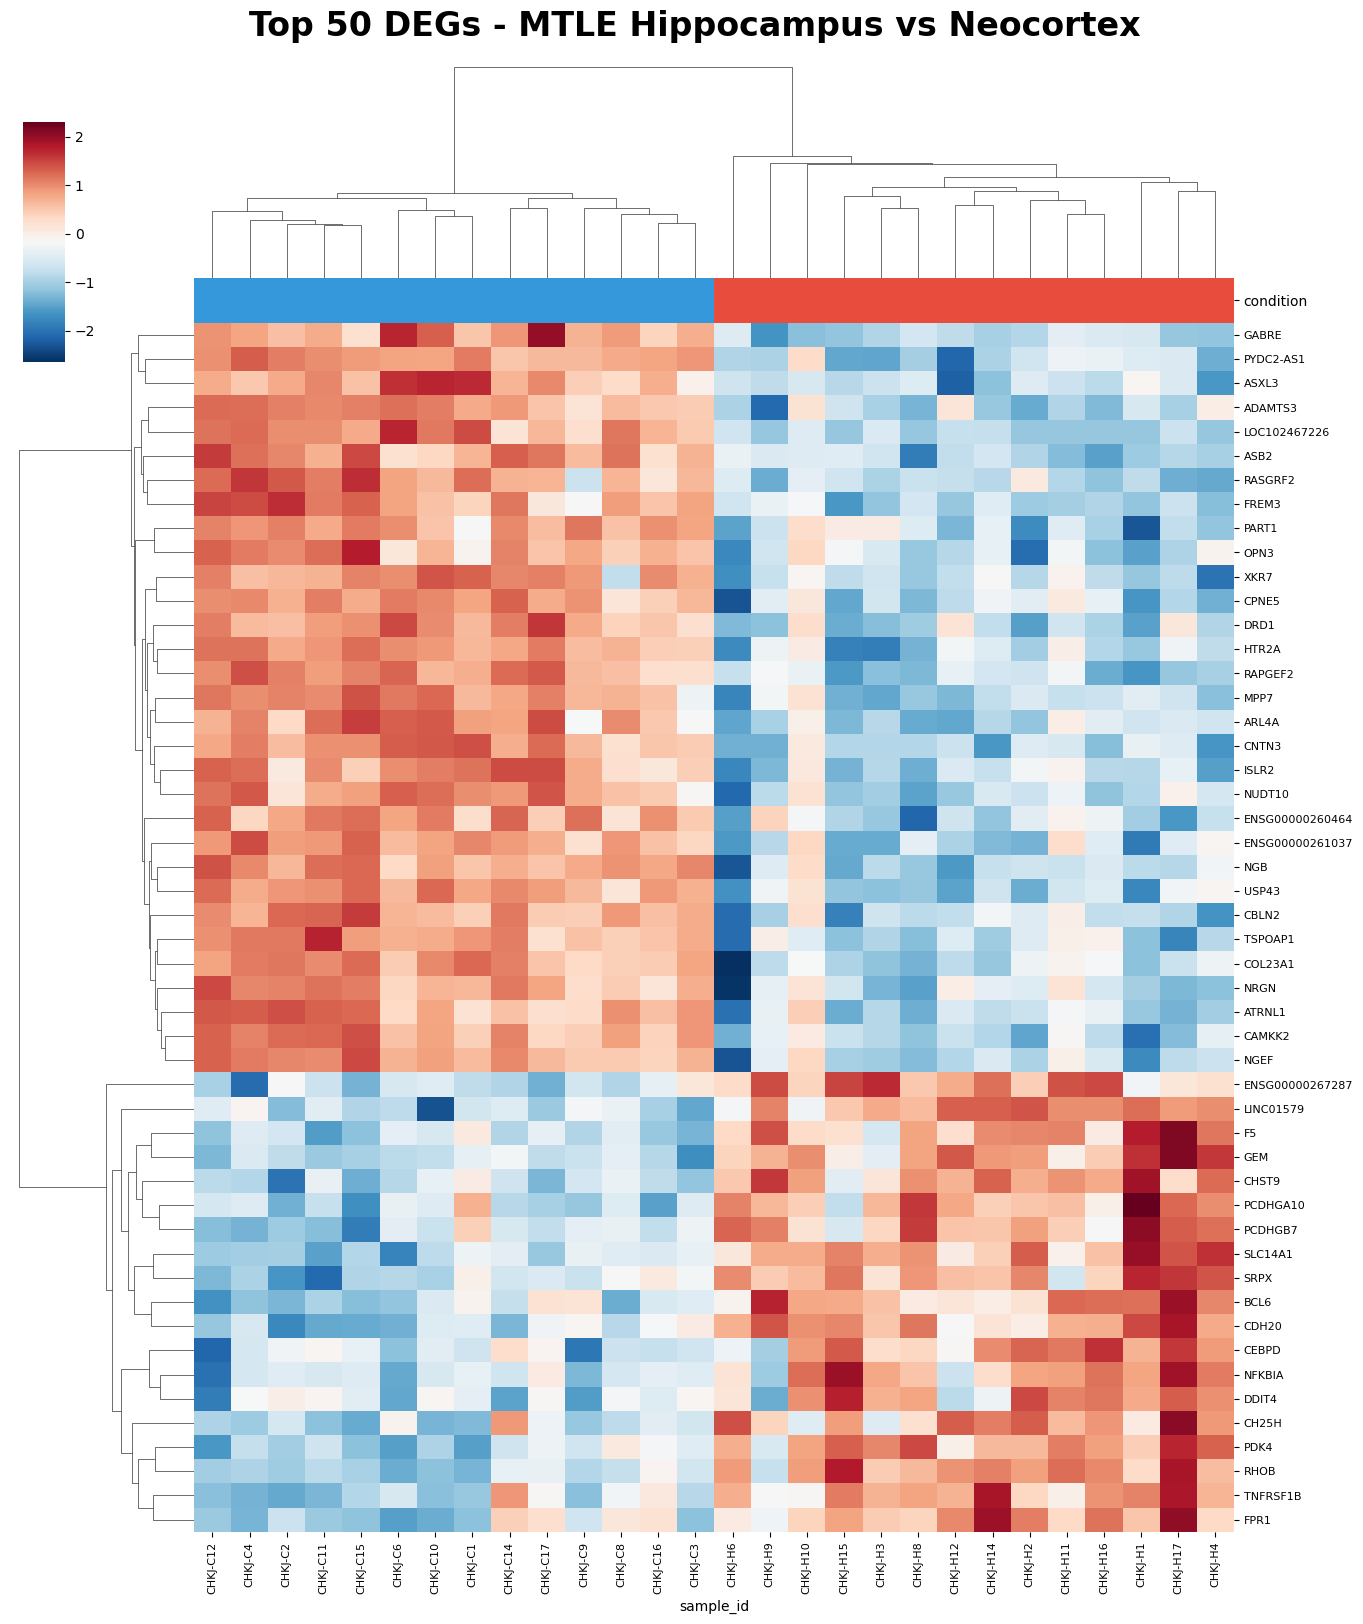

In [114]:
# Plot the heatmap
import seaborn as sns

# plot the clustered heatmap
heat_map = sns.clustermap(
    heatmap_data,
    # col_colors adds the condition color bar at the top
    col_colors=condition_color,
    #cmap is the color scheme
    cmap='RdBu_r',
    # z_score=0 standardizes each row(gene) to mean 0 std 1
    # This makes genes comparable regardless of their absolute expression
    z_score=0,

    figsize=(14,16),
    xticklabels=True,
    yticklabels=True,
    # dendrogram controls how much sace the tree diagram takes
    dendrogram_ratio=0.15,
    #cbar_pos positions the color scale bar
    cbar_pos=(0.02, 0.8, 0.03, 0.15)    
)

# Adjust the font sizes
heat_map.ax_heatmap.set_xticklabels(
    heat_map.ax_heatmap.get_xticklabels(),
    fontsize=8, rotation=90
)

heat_map.ax_heatmap.set_yticklabels(
    heat_map.ax_heatmap.get_yticklabels(),
    fontsize=8, rotation=0
)


plt.suptitle('Top 50 DEGs - MTLE Hippocampus vs Neocortex',
            y=1.02, fontsize=24, fontweight='bold')
plt.savefig('./data/heatmap_top50.png',
           dpi=300, bbox_inches='tight')
plt.show()

In [121]:
import gseapy as gp
# get the list of significant gene symbols for enrichment analysis
# we use gene symbols and not ensembl IDs because pathway databses use symbols
sig_gene_symbols = sig_genes_fc['gene_symbol'].dropna().tolist()

# remove any gene that still has Ensembl IDs as symbols
# these are genes that couldn't be mapped so we exclude them
sig_gene_symbols_clean = [g for g in sig_gene_symbols
                         if not g.startswith('ENSG')]

sig_gene_symbols_clean[:10]

['LINC02593',
 'SAMD11',
 'PTPN11BP',
 'TNFRSF18',
 'TMEM278',
 'VWA1',
 'TMEM52',
 'GABRD',
 'MMEL1',
 'TP73']

In [118]:
print(f"Significant genes for pathway analysis: {len(sig_gene_symbols_clean)}")
print(f"Example genes: {sig_gene_symbols_clean[:10]}")

Significant genes for pathway analysis: 1540
Example genes: ['LINC02593', 'SAMD11', 'PTPN11BP', 'TNFRSF18', 'TMEM278', 'VWA1', 'TMEM52', 'GABRD', 'MMEL1', 'TP73']


In [122]:
# Now run the pathways enrichment analysis against three databses
# Enrichr is a web based tool that gseapy connects to automatically
# It test whether your gene list is enriched for genes in known pathways

enrichment_results = {}

databases = [
    'GO_Biological_Process_2023', # biological processes enriched
    'KEGG_2021_Human'             # diseases and metabolic pathways
    'WikiPathway_2023_Human'      # curated biological pathways
]

for db in databases:
    print(f"Running enrichmnet against {db}...")

    result = gp.enrichr(
        gene_list=sig_gene_symbols_clean,
        gene_sets=db,
        organism='human',
        outdir=None,  # don't have to store in disk yet, store in memory
        verbose=False    
    )

    enrichment_results[db] =result.results

    # Show top 5 results for each database immediately
    top5 = result.results.sort_values('Adjusted P-value').head(5)
    print(f"\nTop 5 enriched terms in {db}:")
    print(top5[['Term', 'Adjusted P-value', 'Overlap']].to_string())
    print("\n" + "="*60 + "\n")

print("All enrichment analyses complete")

Running enrichmnet against GO_Biological_Process_2023...

Top 5 enriched terms in GO_Biological_Process_2023:
                                                                                                       Term  Adjusted P-value Overlap
0                                                               Chemical Synaptic Transmission (GO:0007268)      3.038170e-09  58/273
1                                                         Anterograde Trans-Synaptic Signaling (GO:0098916)      6.050787e-08  45/199
2                    Adenylate Cyclase-Inhibiting G Protein-Coupled Receptor Signaling Pathway (GO:0007193)      1.128466e-03   16/52
3                    Adenylate Cyclase-Modulating G Protein-Coupled Receptor Signaling Pathway (GO:0007188)      1.864993e-03  31/163
4  G Protein-Coupled Receptor Signaling Pathway, Coupled To Cyclic Nucleotide Second Messenger (GO:0007187)      1.939330e-03   15/50


Running enrichmnet against KEGG_2021_HumanWikiPathway_2023_Human...


2026-03-22 10:27:44,503 [WARNING] Input library not found: KEGG_2021_HumanWikiPathway_2023_Human. Skip


EnrichrValidationError: No GeneSets are valid !!! Check your gene_sets input.

In [123]:
# This queries Enrichr to get the current list of available databases
# Database names change between gseapy versions so we always verify first

import gseapy as gp

# Get all available libraries from Enrichr
available_libs = gp.get_library_name(organism='human')

# Print all libraries containing keywords we care about
keywords = ['GO_Biological', 'KEGG', 'Wiki', 'Pathway']

print("Available databases matching our keywords:")
for lib in available_libs:
    for keyword in keywords:
        if keyword.lower() in lib.lower():
            print(f"  {lib}")
            break

Available databases matching our keywords:
  Elsevier_Pathway_Collection
  GO_Biological_Process_2021
  GO_Biological_Process_2023
  GO_Biological_Process_2025
  KEGG_2013
  KEGG_2015
  KEGG_2016
  KEGG_2019_Human
  KEGG_2019_Mouse
  KEGG_2021_Human
  KEGG_2026
  PFOCR_Pathways_2023
  Reactome_Pathways_2024
  WikiPathway_2021_Human
  WikiPathway_2023_Human
  WikiPathways_2013
  WikiPathways_2015
  WikiPathways_2016
  WikiPathways_2019_Human
  WikiPathways_2019_Mouse
  WikiPathways_2024_Human
  WikiPathways_2024_Mouse


In [124]:
enrichment_results = {}

# Using exact names confirmed from the available libraries list
databases = [
    'GO_Biological_Process_2023',
    'KEGG_2021_Human',
    'WikiPathway_2023_Human'
]

for db in databases:
    print(f"Running enrichment against {db}...")
    
    result = gp.enrichr(
        gene_list=sig_gene_symbols_clean,
        gene_sets=db,
        organism='human',
        outdir=None,
        verbose=False
    )
    
    enrichment_results[db] = result.results
    
    # Show top 5 results for each database
    top5 = result.results.sort_values('Adjusted P-value').head(5)
    print(f"\nTop 5 enriched terms in {db}:")
    print(top5[['Term', 'Adjusted P-value', 'Overlap']].to_string())
    print("\n" + "="*60 + "\n")

print("All enrichment analyses complete")

Running enrichment against GO_Biological_Process_2023...

Top 5 enriched terms in GO_Biological_Process_2023:
                                                                                                       Term  Adjusted P-value Overlap
0                                                               Chemical Synaptic Transmission (GO:0007268)      3.038170e-09  58/273
1                                                         Anterograde Trans-Synaptic Signaling (GO:0098916)      6.050787e-08  45/199
2                    Adenylate Cyclase-Inhibiting G Protein-Coupled Receptor Signaling Pathway (GO:0007193)      1.128466e-03   16/52
3                    Adenylate Cyclase-Modulating G Protein-Coupled Receptor Signaling Pathway (GO:0007188)      1.864993e-03  31/163
4  G Protein-Coupled Receptor Signaling Pathway, Coupled To Cyclic Nucleotide Second Messenger (GO:0007187)      1.939330e-03   15/50


Running enrichment against KEGG_2021_Human...

Top 5 enriched terms in KEGG_2021_Hum

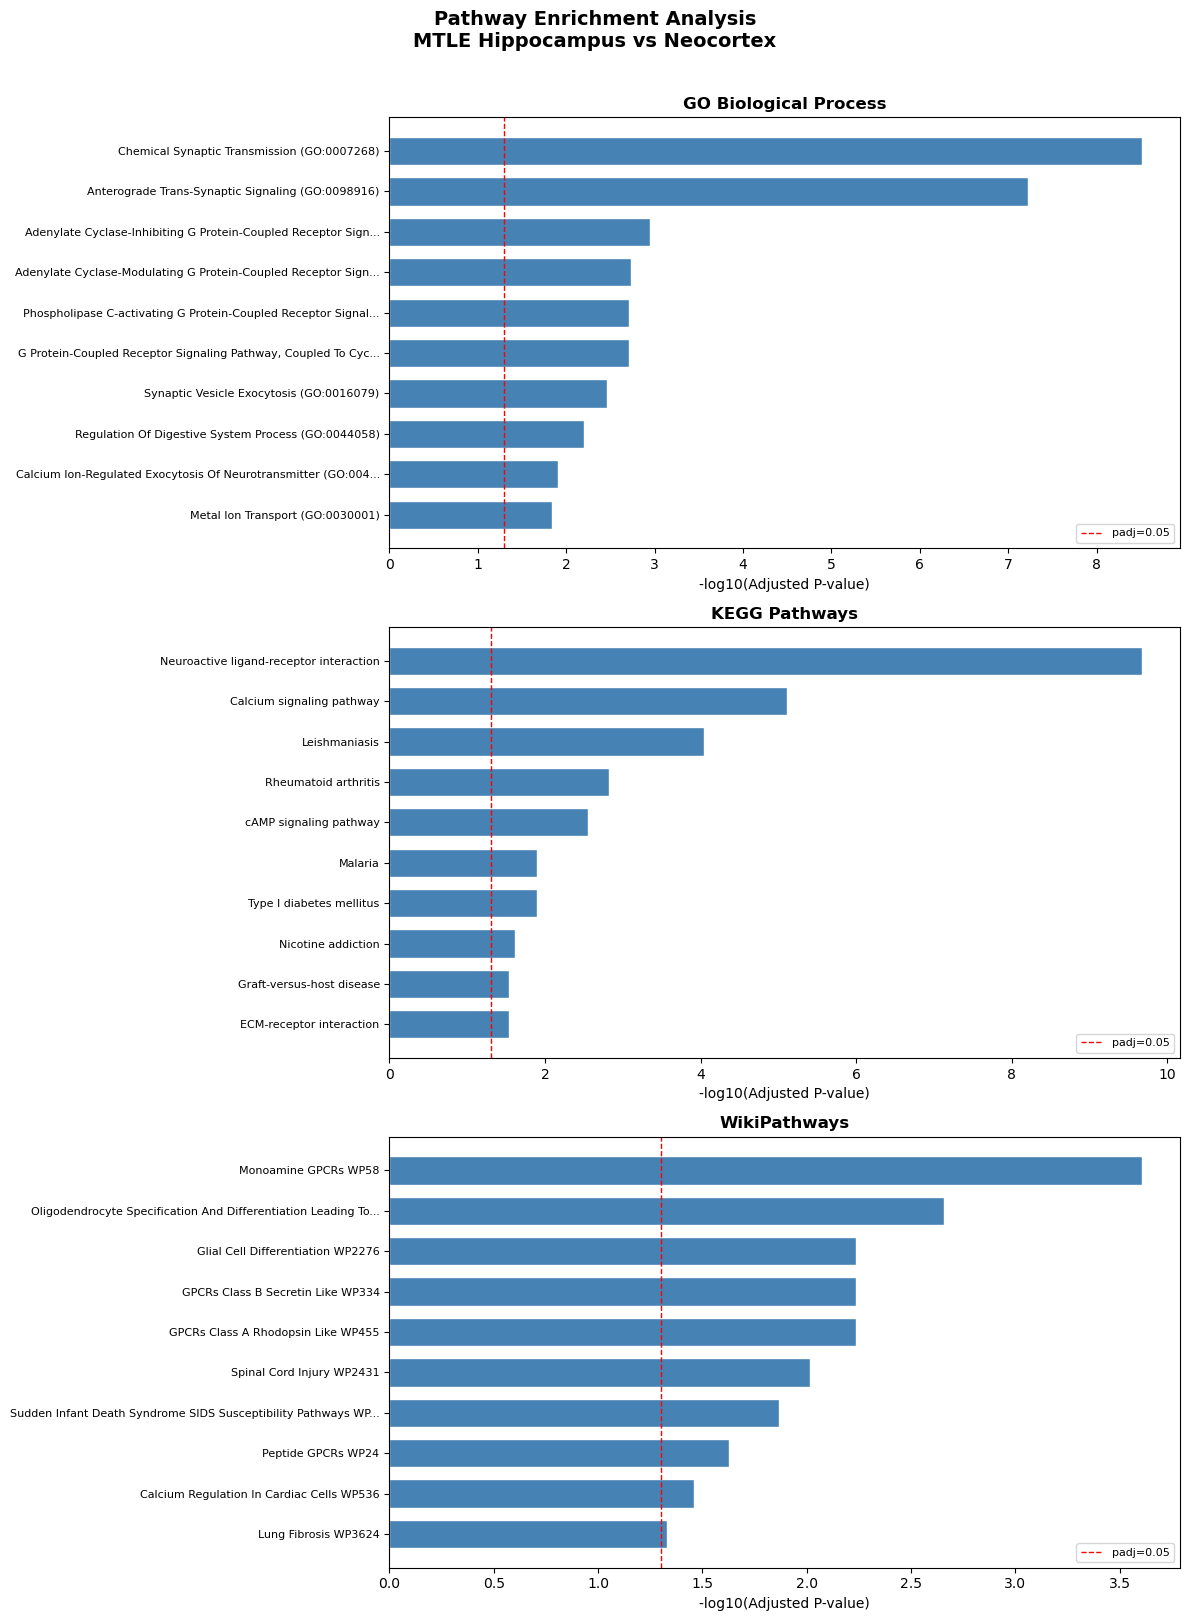

Pathway plot saved


In [125]:
# Plot top enriched terms from each database as a bar chart
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

db_labels = {
    'GO_Biological_Process_2023': 'GO Biological Process',
    'KEGG_2021_Human': 'KEGG Pathways',
    'WikiPathway_2023_Human': 'WikiPathways'
}

for ax, (db, label) in zip(axes, db_labels.items()):
    
    # Get top 10 terms sorted by adjusted p-value
    top10 = enrichment_results[db].sort_values(
        'Adjusted P-value').head(10).copy()
    
    # Calculate -log10 adjusted p-value for x axis
    # More significant = longer bar
    top10['neg_log10_padj'] = -np.log10(top10['Adjusted P-value'])
    
    # Shorten long term names for readability
    # Keep only first 60 characters if name is too long
    top10['Short Term'] = top10['Term'].apply(
        lambda x: x[:60] + '...' if len(x) > 60 else x
    )
    
    # Sort so most significant appears at top
    top10 = top10.sort_values('neg_log10_padj', ascending=True)
    
    # Create horizontal bar chart
    bars = ax.barh(
        top10['Short Term'],
        top10['neg_log10_padj'],
        color='steelblue',
        edgecolor='white',
        height=0.7
    )
    
    # Add significance threshold line at padj=0.05
    ax.axvline(x=-np.log10(0.05), color='red',
               linestyle='--', linewidth=1, label='padj=0.05')
    
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=10)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Pathway Enrichment Analysis\nMTLE Hippocampus vs Neocortex',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./data/pathway_enrichment.png', dpi=300, bbox_inches='tight')
plt.show()

print("Pathway plot saved")